# EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

**Group Members:** Mark Deng, Jun Luu, Sam Sen
**Submission Date:** 4/5/26

---

In this assignment, we explore land use and land cover (LULC) classification, comparing traditional machine learning and deep learning approaches.

---
## 1. Data Loading, Processing, and Exploration

In [1]:
# since we are using google colab, we need to mount our google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, Conv2D, MaxPooling2D,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Global Settings for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

---
### 1.1 Data Preparation

The EuroSAT dataset was downloaded and prepared to support the subsequent machine learning and deep learning tasks.

In [3]:
# set the path to the RGB dataset and image size
RGB_DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/musa650-eurosat/eurosat_files/EuroSAT_RGB")
IMG_SIZE = (64, 64)

# get class names from subfolder names and map each to an integer index
CLASS_NAMES = sorted([d.name for d in RGB_DATA_DIR.iterdir() if d.is_dir()])
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}


In [4]:
# load all images and labels into arrays
images, labels = [], []
for cls in CLASS_NAMES:
    for img_path in sorted((RGB_DATA_DIR / cls).iterdir()):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        img = load_img(img_path, target_size=IMG_SIZE)
        images.append(img_to_array(img).astype(np.uint8))
        labels.append(CLASS_TO_IDX[cls])

images_rgb = np.array(images)
labels = np.array(labels)

print("images_rgb shape:", images_rgb.shape)
print("labels shape:", labels.shape)

images_rgb shape: (27000, 64, 64, 3)
labels shape: (27000,)


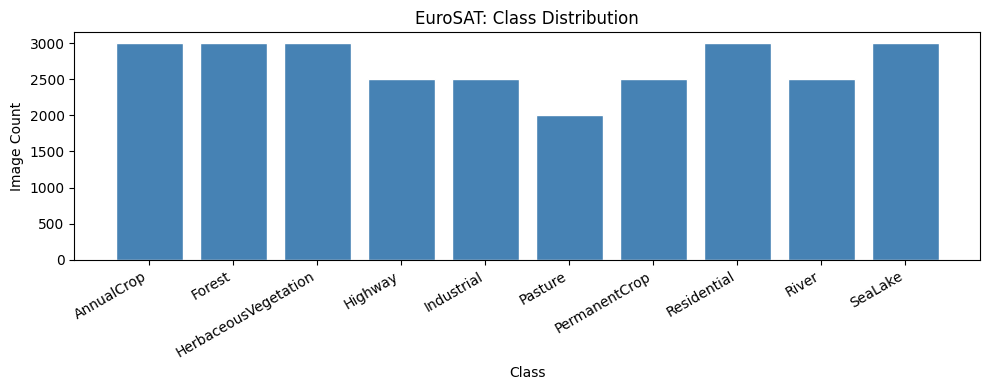

AnnualCrop 3000
Forest 3000
HerbaceousVegetation 3000
Highway 2500
Industrial 2500
Pasture 2000
PermanentCrop 2500
Residential 3000
River 2500
SeaLake 3000


In [5]:
# plot the class distribution
_, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, counts, color="steelblue", edgecolor="white")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.title("EuroSAT: Class Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# print the count for each class
for cls, count in zip(CLASS_NAMES, counts):
    print(cls, count)

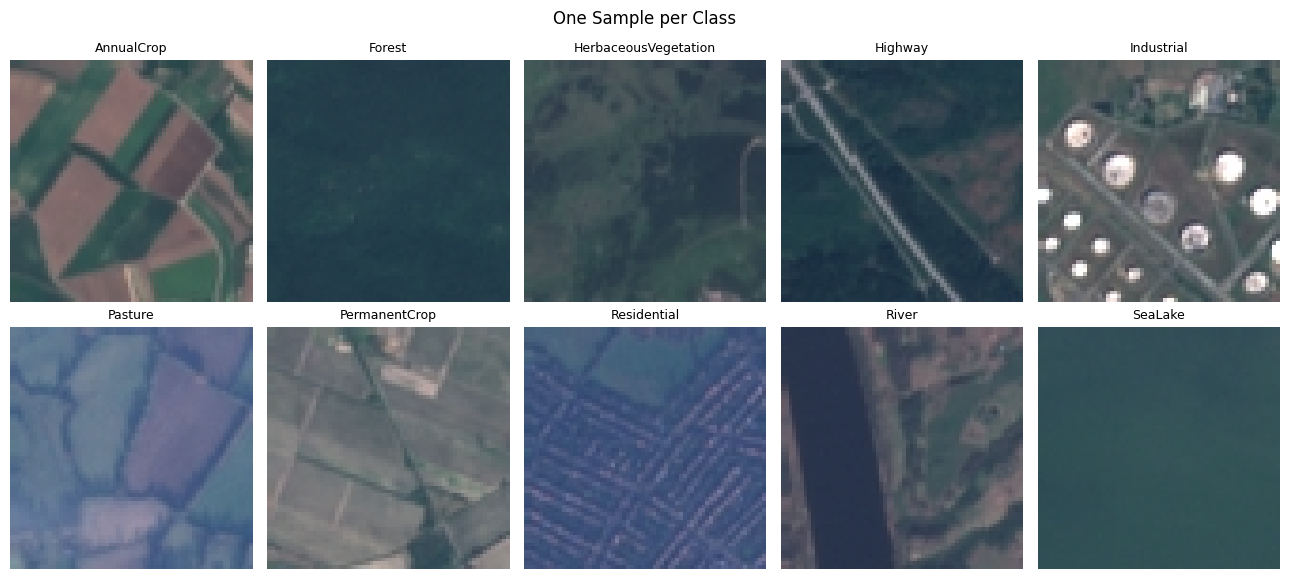

In [6]:
# plot one sample image per class in a 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    # pick a random image from this class
    idx = np.random.choice(np.where(labels == CLASS_TO_IDX[cls])[0])
    axes[i].imshow(images_rgb[idx])
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis("off")

plt.suptitle("One Sample per Class", fontsize=12)
plt.tight_layout()
plt.show()

### 1.2 Data Splitting and Augmentation (Split first)
A train–test split was applied first. We did data augmentation after data splitting within the train set only to avoid data leakage and maintain a pure test set. We used horizontal flip, vertical flip, and rotation to do image augmentation and increase dataset size. Finally, we did greyscale processing.

In [7]:
# apply data augmentation after splitting to avoid data leakage
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    fill_mode="reflect",
)

# split into 60% train and 40% test, stratified by class, using the ORIGINAL data
idx_train, idx_test = train_test_split(
    np.arange(len(images_rgb)),
    test_size=0.40,
    stratify=labels,
    random_state=SEED,
)

X_orig_train, X_orig_test = images_rgb[idx_train], images_rgb[idx_test]
y_orig_train, y_orig_test = labels[idx_train], labels[idx_test]

# function to augment a subset
def augment_subset(X_subset, y_subset):
    aug_imgs = []
    for i in range(len(X_subset)):
        img_expanded = np.expand_dims(X_subset[i], axis=0)
        aug_iter = datagen.flow(img_expanded, batch_size=1, seed=SEED)
        aug_imgs.append(next(aug_iter)[0].astype(np.uint8))
    # combine original and augmented
    return np.concatenate([X_subset, np.array(aug_imgs)], axis=0), np.concatenate([y_subset, y_subset], axis=0)

# generate augmented versions for train set only
X_rgb_train, y_train = augment_subset(X_orig_train, y_orig_train)

# keep test set unmodified, but use the same variable names for downstream cells
X_rgb_test, y_test = X_orig_test, y_orig_test

# combine original and augmented images into one dataset to keep variable names valid for next plots
images_aug = np.concatenate([X_rgb_train, X_rgb_test], axis=0)
labels_aug = np.concatenate([y_train, y_test], axis=0)

print("original dataset size:", len(images_rgb))
print("augmented train set size:", len(X_rgb_train))
print("unmodified test set size:", len(X_rgb_test))
print("combined dataset size:", len(images_aug))


original dataset size: 27000
augmented train set size: 32400
unmodified test set size: 10800
combined dataset size: 43200


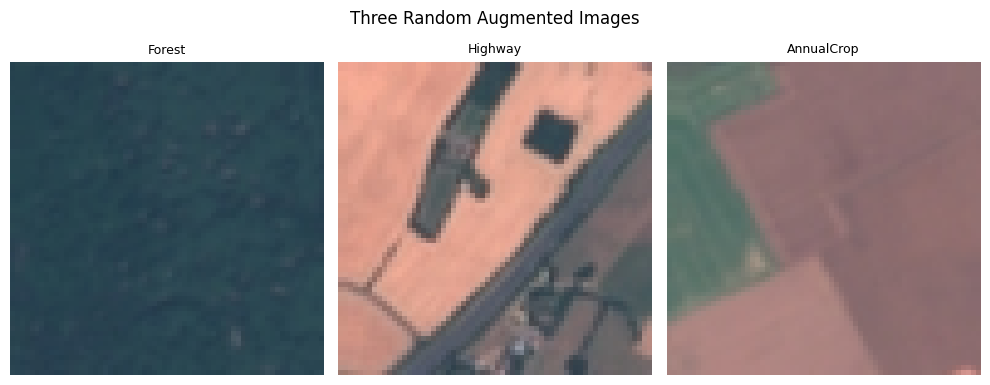

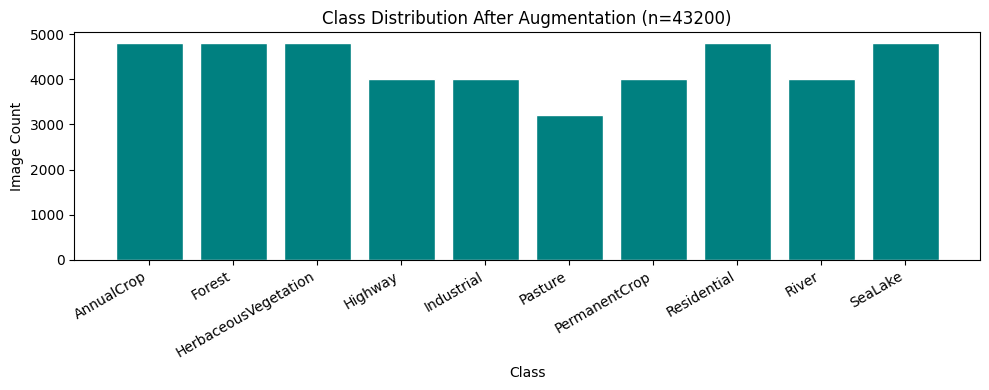

In [8]:
# plot three random augmented images
aug_only_indices = np.arange(len(images_rgb), len(images_aug))
sample_idx = np.random.choice(aug_only_indices, size=3, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, idx in zip(axes, sample_idx):
    ax.imshow(images_aug[idx])
    ax.set_title(CLASS_NAMES[labels_aug[idx]], fontsize=9)
    ax.axis("off")

plt.suptitle("Three Random Augmented Images", fontsize=12)
plt.tight_layout()
plt.show()

# plot the class distribution after augmentation
_, counts_aug = np.unique(labels_aug, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, counts_aug, color="teal", edgecolor="white")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.title("Class Distribution After Augmentation (n=" + str(len(labels_aug)) + ")")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 1.3 Greyscale Processing

In [10]:
print("train samples (augmented):", len(X_rgb_train))
print("test samples:", len(X_rgb_test))

# convert augmented images to grayscale using luminance weights: gray = 0.299R + 0.587G + 0.114B
X_gray_train = np.dot(X_rgb_train[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)
X_gray_test = np.dot(X_rgb_test[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

# flatten each 64x64 grayscale image into a 1D vector of length 4096 (64*64=4096)
X_flat_train = X_gray_train.reshape(len(X_gray_train), -1)
X_flat_test = X_gray_test.reshape(len(X_gray_test), -1)

print("X_gray_train shape:", X_gray_train.shape)
print("X_flat_train shape:", X_flat_train.shape)


train samples (augmented): 32400
test samples: 10800
X_gray_train shape: (32400, 64, 64)
X_flat_train shape: (32400, 4096)


---
## 2. Traditional Machine Learning

For this section, we focus on three categories: "Forest (F)", "Residential (R)", and "Industrial (I)". We subset the grayscale dataset, selecting only these three classes.

In [11]:
# subset the flattened grayscale data to only Forest, Residential, and Industrial
# these are the class indices we need
forest_idx      = CLASS_TO_IDX["Forest"]
residential_idx = CLASS_TO_IDX["Residential"]
industrial_idx  = CLASS_TO_IDX["Industrial"]

# create a mask for only these three classes in train and test sets
train_mask = np.isin(y_train, [forest_idx, residential_idx, industrial_idx])
test_mask  = np.isin(y_test,  [forest_idx, residential_idx, industrial_idx])

# apply the mask to get the subsetted flat grayscale arrays and labels
# Normalize the pixel values to [0, 1] for better SVM convergence and performance
X_train_3 = X_flat_train[train_mask].astype('float32') / 255.0
X_test_3  = X_flat_test[test_mask].astype('float32') / 255.0
y_train_3 = y_train[train_mask]
y_test_3  = y_test[test_mask]

print("train samples:", len(X_train_3))
print("test samples:", len(X_test_3))
print("classes:", np.unique(y_train_3), "->", [CLASS_NAMES[i] for i in np.unique(y_train_3)])

train samples: 10200
test samples: 3400
classes: [1 4 7] -> ['Forest', 'Industrial', 'Residential']


### 2.1 Binary Support Vector Machine

In this step we built three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I].

In [12]:
# helper to filter down to just two classes for binary classification
def get_binary_subset(X_train, y_train, X_test, y_test, class_a, class_b):
    # keep only samples belonging to class_a or class_b
    train_mask = np.isin(y_train, [class_a, class_b])
    test_mask  = np.isin(y_test,  [class_a, class_b])
    return (
        X_train[train_mask], y_train[train_mask],
        X_test[test_mask],   y_test[test_mask]
    )

Forest vs Residential | accuracy: 0.975 | AUC: 0.998
Forest vs Industrial | accuracy: 0.997 | AUC: 1.000
Residential vs Industrial | accuracy: 0.723 | AUC: 0.768


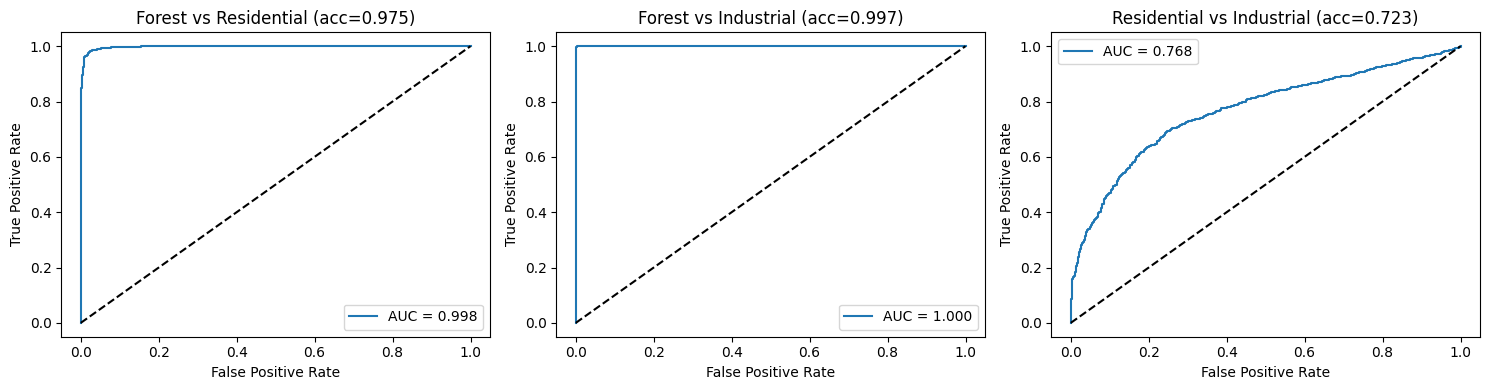

In [13]:
# define the three binary pairs
pairs = [
    ("Forest", "Residential", forest_idx, residential_idx),
    ("Forest", "Industrial", forest_idx, industrial_idx),
    ("Residential", "Industrial", residential_idx, industrial_idx),
]

svm_models = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name_a, name_b, idx_a, idx_b) in zip(axes, pairs):
    X_tr, y_tr, X_te, y_te = get_binary_subset(
        X_train_3, y_train_3, X_test_3, y_test_3, idx_a, idx_b
    )

    # keep default params except for linear kernel
    svm = SVC(kernel="linear")
    svm.fit(X_tr, y_tr)

    svm_models[f"{name_a}_vs_{name_b}"] = (svm, idx_a, idx_b)

    y_pred = svm.predict(X_te)
    acc = accuracy_score(y_te, y_pred)

    # decision_function is positive for svm.classes_[1]
    y_score = svm.decision_function(X_te)
    if svm.classes_[1] != idx_b:
        y_score = -y_score

    fpr, tpr, _ = roc_curve(y_te, y_score, pos_label=idx_b)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{name_a} vs {name_b} (acc={acc:.3f})")
    ax.legend()

    print(f"{name_a} vs {name_b} | accuracy: {acc:.3f} | AUC: {roc_auc:.3f}")

plt.tight_layout()
plt.show()


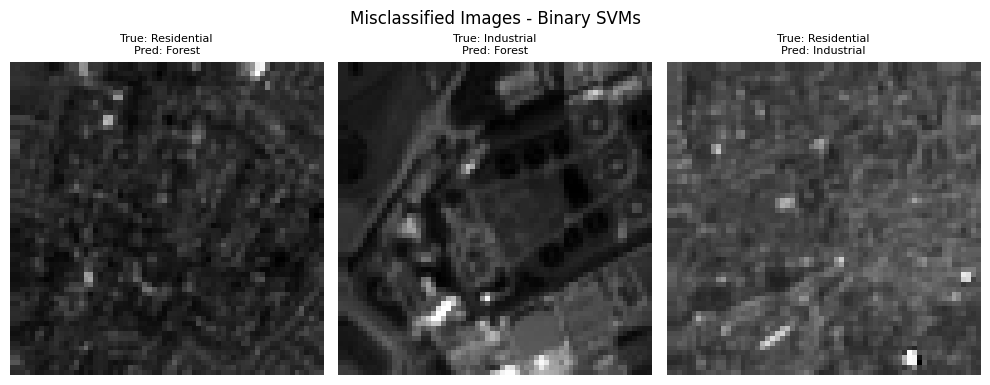

In [14]:
# show one misclassified image for each binary classifier
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, (name_a, name_b, idx_a, idx_b) in zip(axes, pairs):
    svm, _, _ = svm_models[f"{name_a}_vs_{name_b}"]

    X_tr, y_tr, X_te, y_te = get_binary_subset(
        X_train_3, y_train_3, X_test_3, y_test_3, idx_a, idx_b
    )

    y_pred = svm.predict(X_te)
    misclassified = np.where(y_pred != y_te)[0]

    if len(misclassified) == 0:
        ax.set_title(f"{name_a} vs {name_b}\n(no errors)", fontsize=8)
        ax.axis("off")
        continue

    i = misclassified[0]
    true_label = CLASS_NAMES[y_te[i]]
    pred_label = CLASS_NAMES[y_pred[i]]

    ax.imshow(X_te[i].reshape(64, 64), cmap="gray")
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=8)
    ax.axis("off")

plt.suptitle("Misclassified Images - Binary SVMs", fontsize=12)
plt.tight_layout()
plt.show()


### 2.1 Reflection
The linear SVMs performed very well on two of the three binary tasks. Forest vs Residential reached an accuracy of **0.975** with an AUC of **0.998**, and Forest vs Industrial was nearly perfectly separable with an accuracy of **0.997** and an AUC of **1.000**. Residential vs Industrial was much harder, with a lower accuracy of **0.723** and an AUC of **0.768**. This suggests that Forest has a more distinct grayscale pattern, while Residential and Industrial share more similar visual textures and are therefore easier to confuse.


### 2.2 Multiclass, Majority-Vote SVM

Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.



In [15]:
classes = [forest_idx, residential_idx, industrial_idx]
class_lbls = ["Forest", "Residential", "Industrial"]
class_to_col = {cls: i for i, cls in enumerate(classes)}

def majority_vote_with_scores(X_test, svm_models):
    votes = np.zeros((len(X_test), len(classes)), dtype=int)
    scores = np.zeros((len(X_test), len(classes)), dtype=float)

    for svm, idx_a, idx_b in svm_models.values():
        margins = svm.decision_function(X_test)

        if svm.classes_[1] != idx_b:
            margins = -margins

        preds = np.where(margins >= 0, idx_b, idx_a)

        for i, pred in enumerate(preds):
            votes[i, class_to_col[pred]] += 1

        scores[:, class_to_col[idx_a]] += -margins
        scores[:, class_to_col[idx_b]] += margins

    y_pred = []
    for i in range(len(X_test)):
        winners = np.flatnonzero(votes[i] == votes[i].max())
        if len(winners) == 1:
            y_pred.append(classes[winners[0]])
        else:
            best = winners[np.argmax(scores[i, winners])]
            y_pred.append(classes[best])

    return np.array(y_pred), votes, scores

y_pred_mv, vote_matrix, score_matrix = majority_vote_with_scores(X_test_3, svm_models)
acc_mv = accuracy_score(y_test_3, y_pred_mv)
print("majority vote accuracy:", round(acc_mv, 3))

majority vote accuracy: 0.809


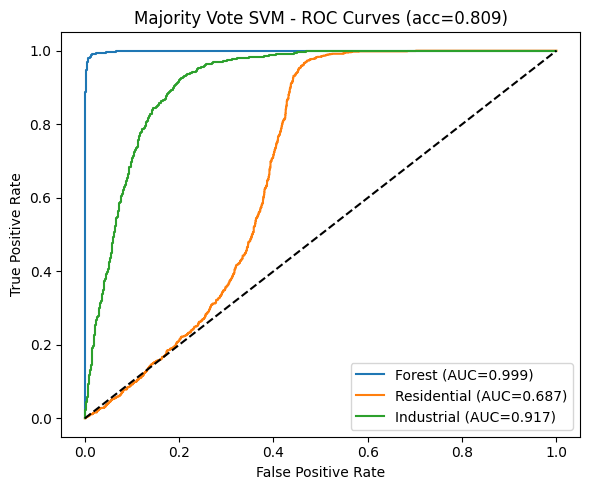

In [16]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test_3, classes=classes)

fig, ax = plt.subplots(figsize=(6, 5))

for i, label in enumerate(class_lbls):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], score_matrix[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"Majority Vote SVM - ROC Curves (acc={acc_mv:.3f})")
ax.legend()
plt.tight_layout()
plt.show()


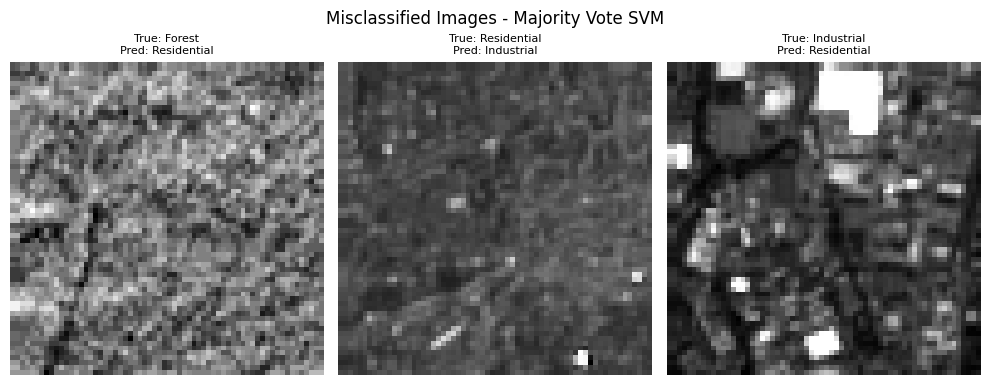

In [17]:
# show one misclassified image per class for the majority vote classifier
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, (cls_idx, cls_name) in zip(axes, zip(classes, class_lbls)):
    # find samples that are truly this class but were misclassified
    mask          = (y_test_3 == cls_idx) & (y_pred_mv != y_test_3)
    misclassified = np.where(mask)[0]

    # skip if no misclassified samples for this class
    if len(misclassified) == 0:
        ax.set_title(cls_name + "\n(no errors)", fontsize=8)
        ax.axis("off")
        continue

    i          = misclassified[0]
    true_label = CLASS_NAMES[y_test_3[i]]
    pred_label = CLASS_NAMES[y_pred_mv[i]]

    ax.imshow(X_test_3[i].reshape(64, 64), cmap="gray")
    ax.set_title("True: " + true_label + "\nPred: " + pred_label, fontsize=8)
    ax.axis("off")

plt.suptitle("Misclassified Images - Majority Vote SVM", fontsize=12)
plt.tight_layout()
plt.show()

#### 2.2 Reflection
Combining the three binary SVMs into a majority-vote classifier produced a test accuracy of **0.809**. The one-vs-rest ROC curves indicate that Forest remains the easiest class to identify, while Residential and Industrial continue to be the most difficult pair. Overall, majority voting provides a reasonable multiclass baseline, but it still inherits the weaknesses of the underlying binary models when class boundaries are less distinct.


### 2.3 Multiclass Random Forest

We trained a Random-Forest classifier to classify the data into one of the three classes in this step.

In [18]:
# train a random forest classifier on the three-class grayscale data
rf = RandomForestClassifier(random_state=SEED)
rf.fit(X_train_3, y_train_3)

y_pred_rf = rf.predict(X_test_3)
acc_rf    = accuracy_score(y_test_3, y_pred_rf)
print("random forest accuracy:", round(acc_rf, 3))

random forest accuracy: 0.912


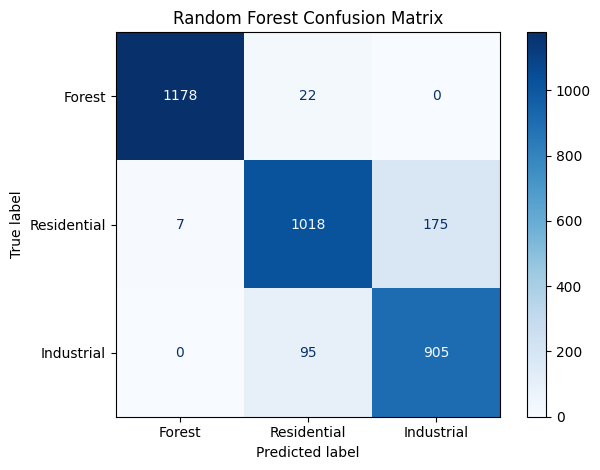

In [19]:
# plot the confusion matrix for the random forest classifier
cm      = confusion_matrix(y_test_3, y_pred_rf, labels=classes)
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_lbls)

cm_disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

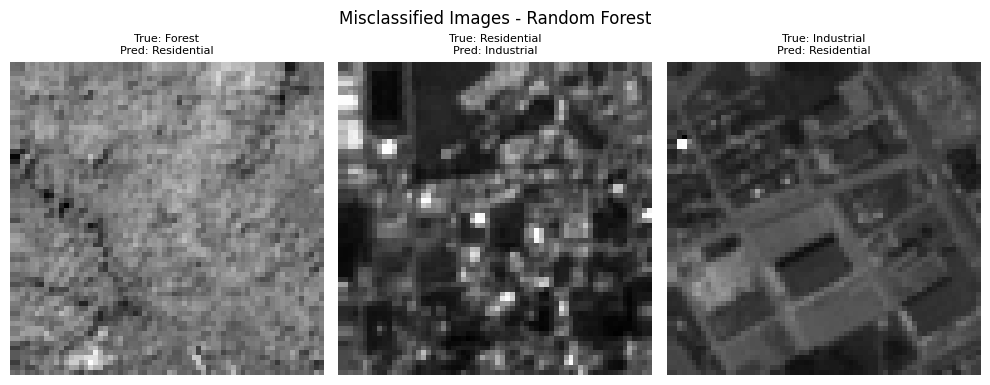

In [20]:
# show one misclassified image per class for the random forest classifier
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, (cls_idx, cls_name) in zip(axes, zip(classes, class_lbls)):
    mask          = (y_test_3 == cls_idx) & (y_pred_rf != y_test_3)
    misclassified = np.where(mask)[0]

    i          = misclassified[0]
    true_label = CLASS_NAMES[y_test_3[i]]
    pred_label = CLASS_NAMES[y_pred_rf[i]]

    ax.imshow(X_test_3[i].reshape(64, 64), cmap="gray")
    ax.set_title("True: " + true_label + "\nPred: " + pred_label, fontsize=8)
    ax.axis("off")

plt.suptitle("Misclassified Images - Random Forest", fontsize=12)
plt.tight_layout()
plt.show()

#### 2.3 Reflection
The Random Forest achieved the strongest performance among the traditional machine learning models, with a test accuracy of **0.912**. The confusion matrix and misclassified examples show that most remaining errors occur between Residential and Industrial rather than involving Forest. This model likely benefits from its ability to capture nonlinear decision boundaries and interactions among pixel features, making it more flexible than the linear SVMs on this three-class grayscale task.


---
## 3. Deep Learning
For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.

### 3.1 Greyscale Images
In this section, we used the greyscale images for fully connected neural network model.

#### 3.1.1 Single-Layer Neural Network
First deep learning model with a fully connected network with a single fully connected layer

Because this is a multiclass classification task, the labels need to be converted into one-hot vectors so that they match the softmax output format of the network. This allows the model to compare the predicted class probabilities with the true class labels correctly during training.

**Pre-Processing**
1. **Normalization:** Pixel values were scaled to a range of [0, 1]. This ensures numeric stability, helps the gradient descent algorithm converge faster, and prevents features with larger numerical ranges from dominating the learning process.
2. **One-Hot Encoding:**
Because this is a multiclass classification task, the labels need to be converted into one-hot vectors so that they match the softmax output format of the network. This allows the model to compare the predicted class probabilities with the true class labels correctly during training. This is required because the model's output layer uses a `softmax` activation and is evaluated using `categorical_crossentropy` loss, which expects mutually exclusive target probability distributions rather than ordinal integers.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

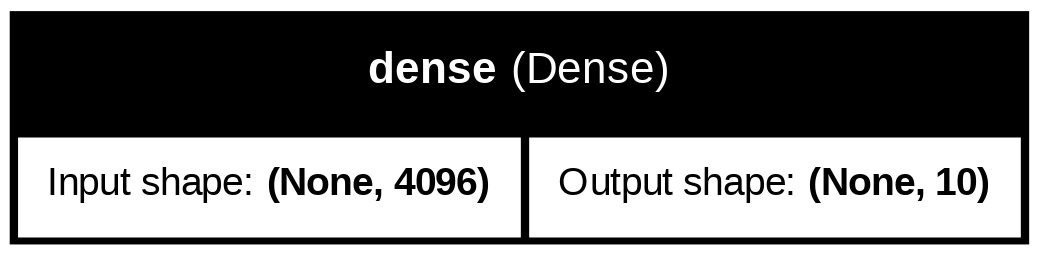

In [21]:
# Pre-processing
# Normalize pixel values to [0, 1]
X_train_nn = X_flat_train.astype('float32') / 255.0
X_test_nn = X_flat_test.astype('float32') / 255.0

# One-hot encode the categorical labels (10 classes in total)
num_classes = len(CLASS_NAMES)
y_train_nn = to_categorical(y_train, num_classes)
y_test_nn = to_categorical(y_test, num_classes)

# Model Architecture
# Single fully connected layer (input shape is 4096 flat pixels)
model_1 = Sequential([
    Dense(num_classes, activation='softmax', input_shape=(4096,))
])

# Compile the model
model_1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Visualization
# Display the model summary and plot the architecture
model_1.summary()
display(plot_model(model_1, show_shapes=True, show_layer_names=True))


In [22]:
# Training
print("\nTraining the model...")
history_1 = model_1.fit(
    X_train_nn, y_train_nn,
    epochs=50, # can be increased
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluation
test_loss, test_acc = model_1.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")


Training the model...
Epoch 1/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1485 - loss: 2.3506 - val_accuracy: 0.2565 - val_loss: 2.1837
Epoch 2/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1856 - loss: 2.2747 - val_accuracy: 0.2904 - val_loss: 2.1436
Epoch 3/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2117 - loss: 2.2300 - val_accuracy: 0.2988 - val_loss: 2.1124
Epoch 4/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2299 - loss: 2.1929 - val_accuracy: 0.3025 - val_loss: 2.0868
Epoch 5/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2413 - loss: 2.1613 - val_accuracy: 0.3034 - val_loss: 2.0652
Epoch 6/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2515 - loss: 2.1340 - val_accuracy: 0.3060 - val_loss: 2.0470
Epoch 7/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2590 - loss: 2.1101 - val_accuracy: 0.3083 - val_loss: 2.0314
Epoch 8/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2650 - loss: 2.

#### 3.1.1 Reflection
**Accuracy & Pre-processing:**
The single-layer model achieved a test accuracy of approximately **29.66%**.


#### 3.1.2 Two-Layer Neural Network
The second deep learning model with an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

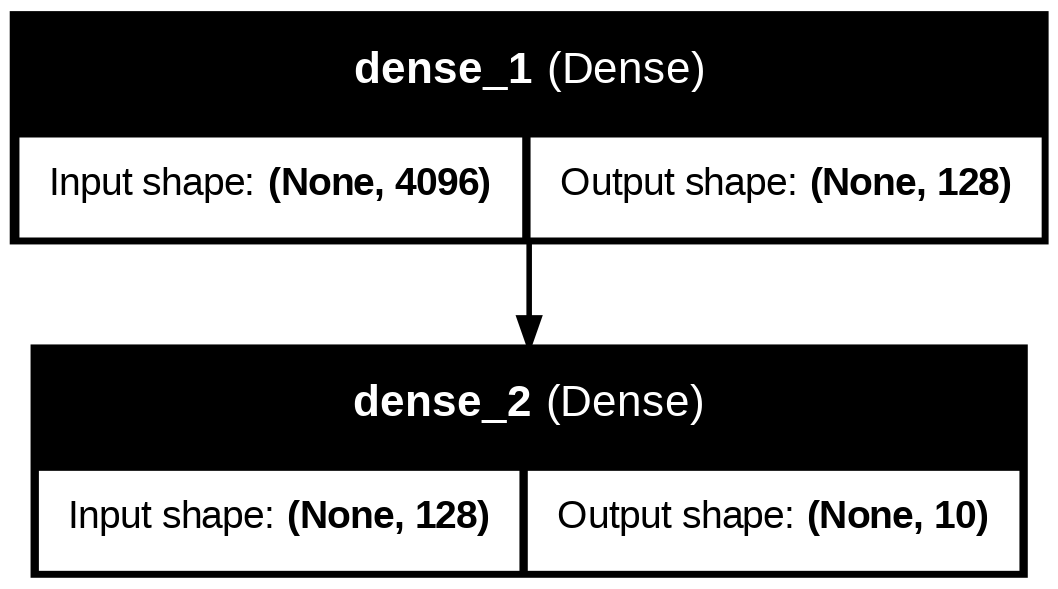

In [23]:
# Model Architecture - Two Layer (1 Hidden + 1 Output)
model_2 = Sequential([
    Dense(128, activation='relu', input_shape=(4096,)), # Hidden layer with 128 nodes
    Dense(num_classes, activation='softmax')           # Output layer
])

# Compile
model_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Setup Checkpoint to save the best model weights
checkpoint_path = "best_model_312.keras"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Model Visualization
model_2.summary()
display(plot_model(model_2, show_shapes=True, show_layer_names=True))


In [24]:
# Training with the Checkpoint callback
print("\nTraining the Two-Layer model...")
history_2 = model_2.fit(
    X_train_nn, y_train_nn,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint],
    verbose=1
)

# Load the best weights found during training, contorl overfitting
if os.path.exists(checkpoint_path):
    print("\nLoading best weights for evaluation...")
    model_2.load_weights(checkpoint_path)

# Final Evaluation on Test Set
test_loss_2, test_acc_2 = model_2.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"\nTest Accuracy (using best epoch weights): {test_acc_2:.4f}")


Training the Two-Layer model...
Epoch 1/50
797/810 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1192 - loss: 2.3133
Epoch 1: val_accuracy improved from None to 0.11698, saving model to best_model_312.keras

Epoch 1: finished saving model to best_model_312.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1214 - loss: 2.2725 - val_accuracy: 0.1170 - val_loss: 2.2289
Epoch 2/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1680 - loss: 2.2177
Epoch 2: val_accuracy improved from 0.11698 to 0.22762, saving model to best_model_312.keras

Epoch 2: finished saving model to best_model_312.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1791 - loss: 2.1997 - val_accuracy: 0.2276 - val_loss: 2.1545
Epoch 3/50
802/810 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1947 - loss: 2.1454
Epoch 3: val_accuracy improved from 0.22762 to 0.23889, saving model to best_model_312.keras

Epoch 3: finished saving model to best_model_312.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s

#### 3.1.2 Reflection
**Accuracy & Hidden Layer Impact:**
Adding an additional hidden layer decreased the test accuracy to approximately **25.31%**.

**Why additional layers improve or worsen accuracy:**
- **Improvement:** Additional hidden layers increase the model's capacity to learn complex, non-linear, and hierarchical representations from the raw flattened pixels.
- **Worsening:** If too many layers are added, the model may overfit the training data, suffer from vanishing/exploding gradients during backpropagation. A checkpoint was used to retain the model with the highest validation accuracy, ensuring that an overfitted model from later epochs was not selected as the final output. However, the results still indicate signs of overfitting in the later training stages. As the result, this model's test accuracy is lower than the single layer model

#### 3.1.3 Four-Layer Neural Network with Dropout


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,634 (4.16 MB)

 Trainable params: 1,090,634 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

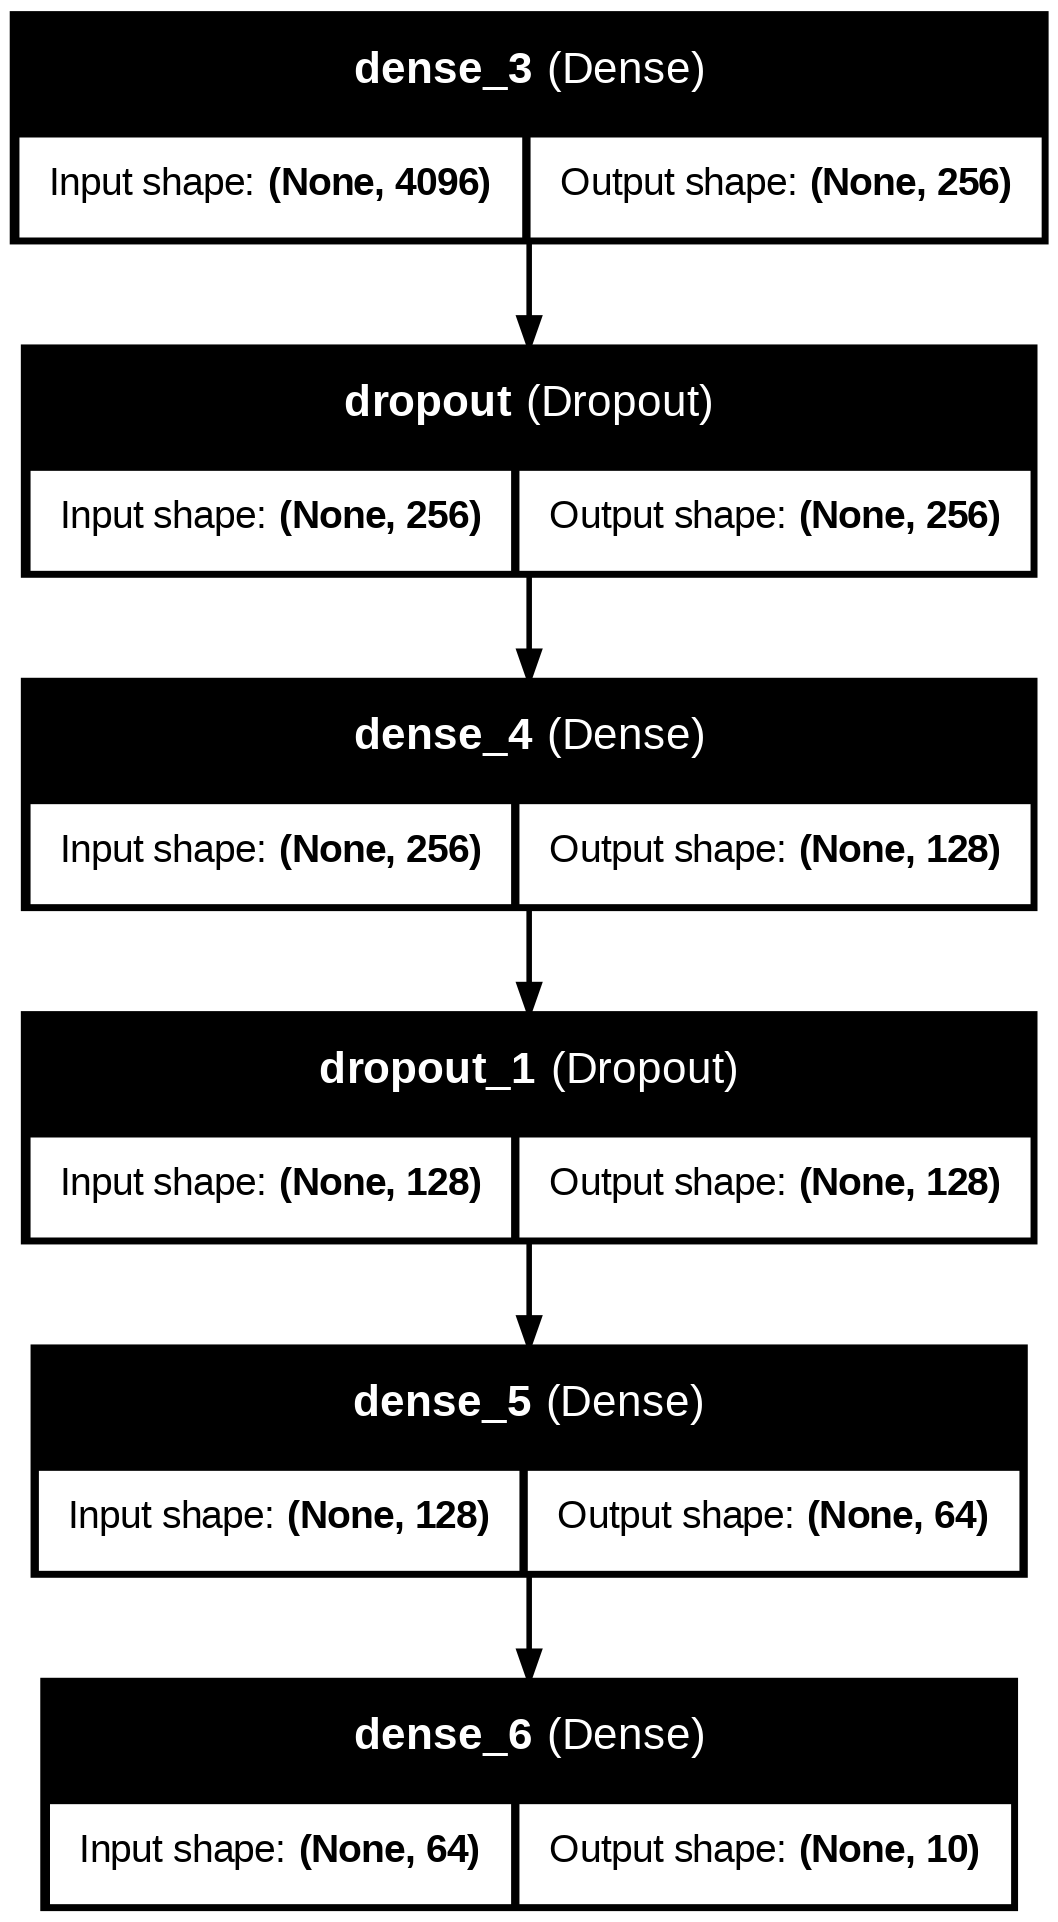

In [25]:
# Model Architecture - Four Layers with Dropout
# (3 Hidden Layers + 1 Output Layer)
model_3 = Sequential([
    Dense(256, activation='relu', input_shape=(4096,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile
model_3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Setup Checkpoint
checkpoint_path_3 = "best_model_313.keras"
checkpoint_3 = ModelCheckpoint(
    filepath=checkpoint_path_3,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Model Visualization
model_3.summary()
display(plot_model(model_3, show_shapes=True, show_layer_names=True))

In [26]:
# Training
print("\nTraining the Four-Layer model with Dropout...")
history_3 = model_3.fit(
    X_train_nn, y_train_nn,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint_3],
    verbose=1
)

# Load Best Weights
if os.path.exists(checkpoint_path_3):
    print("\nLoading best weights for evaluation...")
    model_3.load_weights(checkpoint_path_3)

# Evaluation
test_loss_3, test_acc_3 = model_3.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"\nTest Accuracy (with Dropout & Best Weights): {test_acc_3:.4f}")


Training the Four-Layer model with Dropout...
Epoch 1/50
795/810 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1274 - loss: 2.3040
Epoch 1: val_accuracy improved from None to 0.17855, saving model to best_model_313.keras

Epoch 1: finished saving model to best_model_313.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1572 - loss: 2.2228 - val_accuracy: 0.1785 - val_loss: 2.1228
Epoch 2/50
809/810 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1944 - loss: 2.0849
Epoch 2: val_accuracy did not improve from 0.17855
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2007 - loss: 2.0592 - val_accuracy: 0.1531 - val_loss: 2.2472
Epoch 3/50
793/810 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2031 - loss: 2.0261
Epoch 3: val_accuracy did not improve from 0.17855
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2037 - loss: 2.0179 - val_accuracy: 0.1699 - val_loss: 2.4590
Epoch 4/50
798/810 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2119 - loss: 2.0050
Epoch 4: 

#### 3.1.3 Reflection
**Accuracy & Dropout Impact:**
The test accuracy dropped  to approximately **17.98%** with the introduction of four layers and dropout.

**Role of Dropout:**
Dropout is a regularization technique that randomly sets a fraction of input units to 0 at each update during training time. This forces the network to learn robust, redundant features and prevents complex co-adaptations (overfitting).

**Effectiveness:**
- **More effective:** When a model is large, highly parameterized, and prone to overfitting on a complex dataset.
- **Less effective (as observed here):** If applied too aggressively (e.g., high dropout rates) on a model or dataset that is already struggling to capture the underlying signal, it severely limits the network's information capacity, leading to **underfitting**.

#### 3.1.4 Model Comparison and Ensemble

**Model Comparison & Parameters:**
- Model 3 (Four-Layer with Dropout) had the most parameters to learn, totaling 1,090,634. It had 1,049,664 more parameters than Model 1 (40,970 parameters).

**The "Best" Model:**
- **Model 1 (Single-Layer Network)** was surprisingly the best individual model, achieving the highest test accuracy of **29.66%**.
- **Why did the simplest model perform best?** The input data consists of flattened 1D grayscale vectors (4096 pixels). Flattening completely destroys the 2D spatial structures (shapes, edges, textures) that define land cover classes. In this unstructured feature space, the single-layer model (essentially a multinomial logistic regression) learns a simple linear boundary without severely overfitting. As we added hidden layers (Model 2 and Model 3), the parameter count exploded (up to 1M+). Without the spatial inductive biases of a CNN, these overly complex fully-connected networks quickly overfit to the training noise rather than learning generalizable features, leading to worse performance on the test set.

**Impact of Increasing Training Epochs:**
- **Model 1:** Benefited from more epochs to steadily find the optimal linear weights without extreme overfitting.
- **Model 2:** Quickly memorized the training data, leading to a drop in validation accuracy after early epochs. The ModelCheckpoint was essential here.
- **Model 3:** The combination of an overly complex architecture on a difficult flattened dataset, coupled with aggressive dropout, severely hindered its learning capacity, causing it to perform poorly regardless of the number of epochs.

In [27]:
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Get probability predictions from each model
pred_prob_1 = model_1.predict(X_test_nn)
pred_prob_2 = model_2.predict(X_test_nn)
pred_prob_3 = model_3.predict(X_test_nn)

# 2. Ensemble: Soft Voting (Average the probabilities)
ensemble_prob = (pred_prob_1 + pred_prob_2 + pred_prob_3) / 3.0

# 3. Get the final predicted class (index with highest probability)
ensemble_preds = np.argmax(ensemble_prob, axis=1)
y_test_true = np.argmax(y_test_nn, axis=1)

# 4. Calculate Accuracy
ensemble_acc = accuracy_score(y_test_true, ensemble_preds)

print(f"Model 1 (Single Layer) Accuracy: {test_acc:.4f}")
print(f"Model 2 (Two Layer) Accuracy: {test_acc_2:.4f}")
print(f"Model 3 (Four Layer + Dropout) Accuracy: {test_acc_3:.4f}")
print(f"--- Ensemble Model (Soft Voting) Accuracy: {ensemble_acc:.4f} ---")

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Model 1 (Single Layer) Accuracy: 0.2966
Model 2 (Two Layer) Accuracy: 0.2531
Model 3 (Four Layer + Dropout) Accuracy: 0.1798
--- Ensemble Model (Soft Voting) Accuracy: 0.2780 ---


In [ ]:
# Helper to print parameter count comparison
print(f"Model 1 Parameters: {model_1.count_params():,}")
print(f"Model 2 Parameters: {model_2.count_params():,}")
print(f"Model 3 Parameters: {model_3.count_params():,}")

margin = model_3.count_params() - model_1.count_params()
print(f"\nModel 3 has {margin:,} more parameters than Model 1.")

Model 1 Parameters: 40,970
Model 2 Parameters: 525,706
Model 3 Parameters: 1,090,634

Model 3 has 1,049,664 more parameters than Model 1.


**Ensemble Model Performance:**
- The ensemble model achieved an accuracy of **27.80%**. This sits between the best model (Model 1: 29.66%) and the poorer performing models (Model 2: 25.31%, Model 3: 17.98%). In this case, the ensemble failed to outperform the single best model and was actively dragged down by the poorly performing deeper networks.

**Ensemble Approach & Rationale:**
- We implemented a **Soft Voting** ensemble approach. This method takes the raw predicted probability distributions (softmax outputs) from each of the three fully connected models, calculates the average probabilities, and selects the class with the highest average score.
- **Why ensembling usually improves accuracy:** Ensembling generally improves performance by leveraging the "wisdom of the crowd." It reduces the variance of individual models, smooths out individual prediction errors, and creates a more robust final prediction boundary.
- **Why it failed here (The "Weakest Link" effect):** For an ensemble to improve overall accuracy, the base models need to be both reasonably competent and diverse in their errors. However, as seen here, if the base models in the ensemble (like Model 3) perform significantly worse than the best single model, their highly inaccurate predicted probabilities can "pollute" the average, actively negatively skewing the combined results.

### 3.2 RGB Images
For this section, we used the original RGB images.

#### 3.2.1 CNN Model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

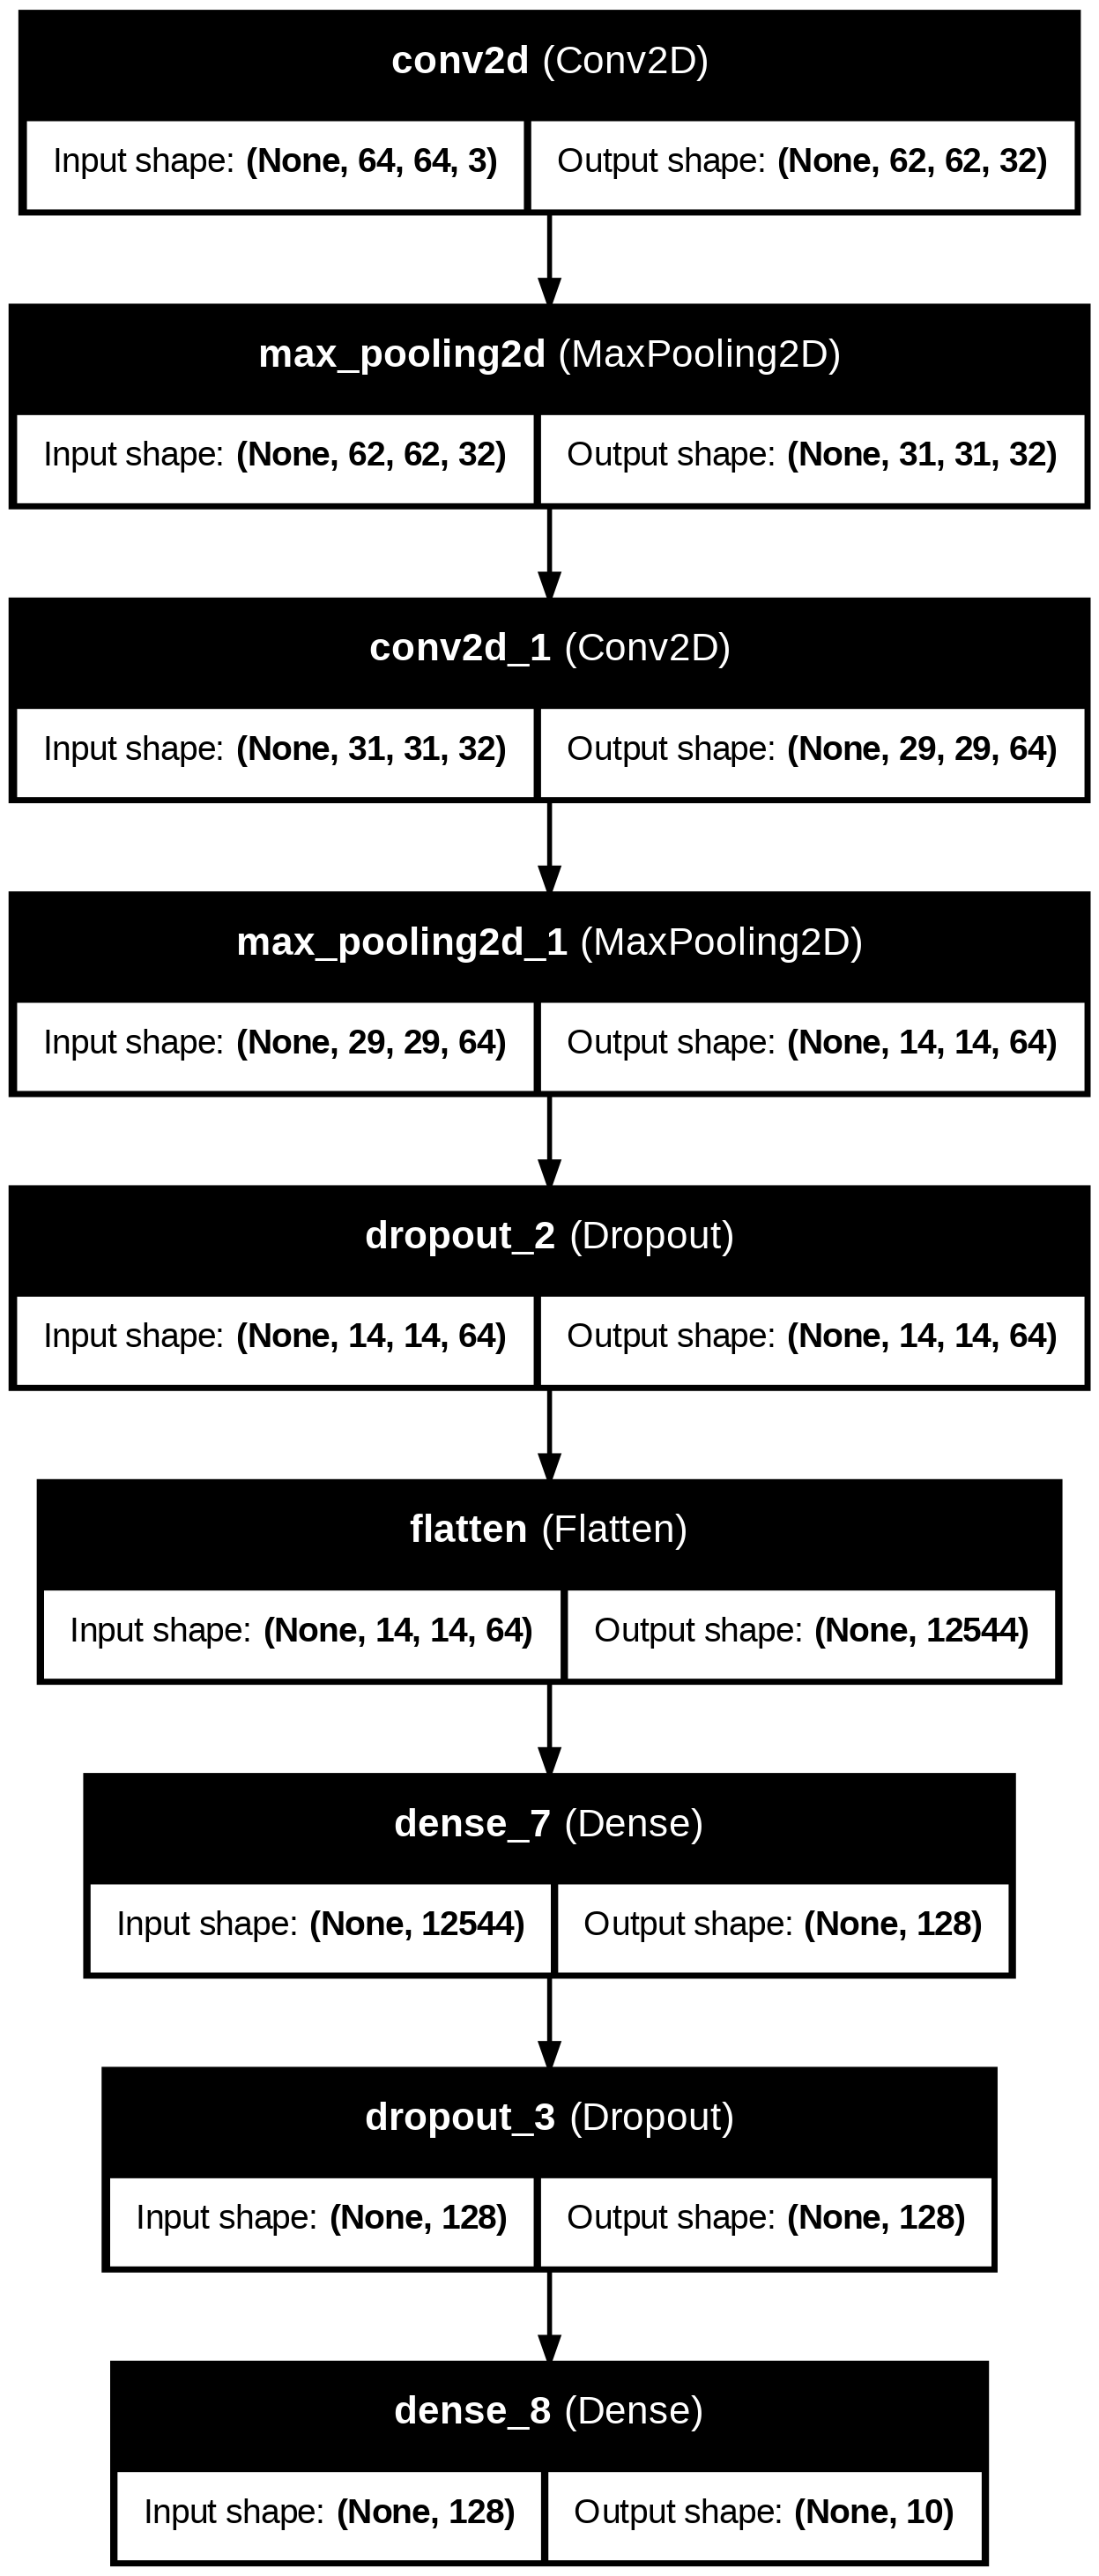

In [28]:
# Pre-process RGB data
# Normalize pixel values to [0, 1]
X_train_rgb = X_rgb_train.astype('float32') / 255.0
X_test_rgb = X_rgb_test.astype('float32') / 255.0

# Reuse one-hot encoded labels from previous sections (y_train_nn, y_test_nn)
# Note: These were created for the full 10 classes in the grayscale section.

# Build CNN Model
model_cnn = Sequential([
    # Convolutional layer with 32 filters, 3x3 kernel
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),

    # Second convolutional layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Dropout for regularization
    Dropout(0.25),

    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile Model
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Visualization
model_cnn.summary()
display(plot_model(model_cnn, show_shapes=True, show_layer_names=True))

In [29]:
# Training
checkpoint_cnn = ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

print("\nTraining CNN model...")
history_cnn = model_cnn.fit(
    X_train_rgb, y_train_nn,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint_cnn],
    verbose=1
)

# Evaluation
if os.path.exists('best_cnn.keras'):
    model_cnn.load_weights('best_cnn.keras')

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test_rgb, y_test_nn, verbose=0)
print(f"\nCNN Test Accuracy: {test_acc_cnn:.4f}")


Training CNN model...
Epoch 1/50
792/810 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3473 - loss: 1.7130
Epoch 1: val_accuracy improved from None to 0.58009, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4515 - loss: 1.4709 - val_accuracy: 0.5801 - val_loss: 1.1600
Epoch 2/50
800/810 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6012 - loss: 1.1224
Epoch 2: val_accuracy improved from 0.58009 to 0.67855, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6234 - loss: 1.0666 - val_accuracy: 0.6785 - val_loss: 0.9274
Epoch 3/50
808/810 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6638 - loss: 0.9637
Epoch 3: val_accuracy improved from 0.67855 to 0.75324, saving model to best_cnn.keras

Epoch 3: finished saving model to best_cnn.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6766 - loss: 0.9198 -

#### 3.2.1 Reflection

**Model Comparison & The "Best" Model:**
- The CNN model is unequivocally the "best" model evaluated so far. It achieved a significantly higher test accuracy (approximately **83.9%**) compared to the best fully connected model (Model 1, **29.66%**). The CNN's architecture is vastly superior at extracting meaningful features from image data.

**Handling Spatial Information & Implications:**
- **Fully Connected Networks (FCNNs):** Require the image to be flattened into a 1D vector, destroying the 2D spatial arrangement of pixels. They treat pixels that are far apart the same as pixels that are right next to each other.
- **CNNs:** Process images in their original 2D/3D structure. By sliding convolutional filters across the image, CNNs capture local spatial relationships (like edges, textures, and shapes).
- **Implications:** This gives CNNs translation invariance. If a feature (e.g., a building or a river) appears in the top-left of one image and the bottom-right of another, the CNN can still recognize it using the same learned filters. This makes CNNs inherently suited for image classification.

**Training Speed & Computational Resources:**
- **Limitation:** The training speed of the CNN was noticeably slower per epoch compared to the simple fully connected networks.
- **Why CNNs require more resources:** While CNNs often have fewer *parameters* than massive fully connected layers (due to weight sharing in the filters), they require far more mathematical operations. Applying multiple filters across every spatial location of the image (and across multiple color channels) involves a massive number of dot products, which takes more time and computational power to calculate.

#### 3.2.2 Advanced Model

**Techniques Used:**
- We utilized **Transfer Learning** by employing a pre-trained **ResNet50** model. The base model (pre-trained on ImageNet) was frozen to retain its learned feature extractors, and we attached a custom classification head (GlobalAveragePooling2D + Dense + Dropout) to map these features to our 10 land cover classes.
- This advanced model achieved an outstanding test accuracy of approximately **92%** and the accuracy is still increasing in 20 epochs (hasn't overfit).

**Why Transfer Learning?**
- Deep neural networks require massive amounts of data and time to learn how to extract useful features (like edges, shapes, and textures) from scratch. By using a model pre-trained on millions of images (ImageNet), we leverage its pre-existing visual understanding. We only had to train the final layers to adapt this general visual knowledge to our specific satellite imagery task. This drastically improved accuracy, reduced training time, and mitigated the risk of overfitting.

**Model Comparison & The "Best" Model:**
- The **ResNet50 Transfer Learning model** is undeniably the "best" model. It vastly outperformed the custom CNN and the basic fully connected networks. Its deep residual architecture (skip connections) allows it to learn highly complex, hierarchical features without suffering from vanishing gradients, making it perfectly suited for challenging image classification tasks.


In [30]:
# Preprocess data specifically for ResNet50
# We use the original uint8 RGB images and apply ResNet's preprocess_input
X_train_resnet = preprocess_input(X_rgb_train.astype('float32'))
X_test_resnet = preprocess_input(X_rgb_test.astype('float32'))

# Load the pre-trained ResNet50 model (without the top classification layer)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze the base model layers so their weights aren't updated during the first phase of training
base_model.trainable = False

# Add custom classification head on top
x = base_model.output
# GlobalAveragePooling2D reduces the spatial dimensions to a 1D vector per feature map
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Combine into the final model
model_resnet = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Visualize the architecture
print("ResNet50 Transfer Learning Model Summary:")
model_resnet.summary()
# Graphviz has a known bug when plotting very complex models like ResNet50, so we rely on summary() instead.
# display(plot_model(model_resnet, show_shapes=True, show_layer_names=False, dpi=60))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 Transfer Learning Model Summary:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
# Training
checkpoint_resnet = ModelCheckpoint('best_resnet.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

print("\nTraining ResNet50 (Feature Extraction head)...")
history_resnet = model_resnet.fit(
    X_train_resnet, y_train_nn,
    epochs=50,  # We can start with 20 epochs for the head
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint_resnet],
    verbose=1
)

# Final Evaluation
if os.path.exists('best_resnet.keras'):
    print("\nLoading best weights for evaluation...")
    model_resnet.load_weights('best_resnet.keras')

test_loss_res, test_acc_res = model_resnet.evaluate(X_test_resnet, y_test_nn, verbose=0)
print(f"\nResNet50 Test Accuracy: {test_acc_res:.4f}")


Training ResNet50 (Feature Extraction head)...
Epoch 1/50
808/810 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8004 - loss: 0.7292
Epoch 1: val_accuracy improved from None to 0.91343, saving model to best_resnet.keras

Epoch 1: finished saving model to best_resnet.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.8583 - loss: 0.4724 - val_accuracy: 0.9134 - val_loss: 0.2383
Epoch 2/50
809/810 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9089 - loss: 0.2859
Epoch 2: val_accuracy improved from 0.91343 to 0.92917, saving model to best_resnet.keras

Epoch 2: finished saving model to best_resnet.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9128 - loss: 0.2739 - val_accuracy: 0.9292 - val_loss: 0.2052
Epoch 3/50
807/810 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9234 - loss: 0.2264
Epoch 3: val_accuracy improved from 0.92917 to 0.94105, saving model to best_resnet.keras

Epoch 3: finished saving model to best_resnet.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 8s 

338/338 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step


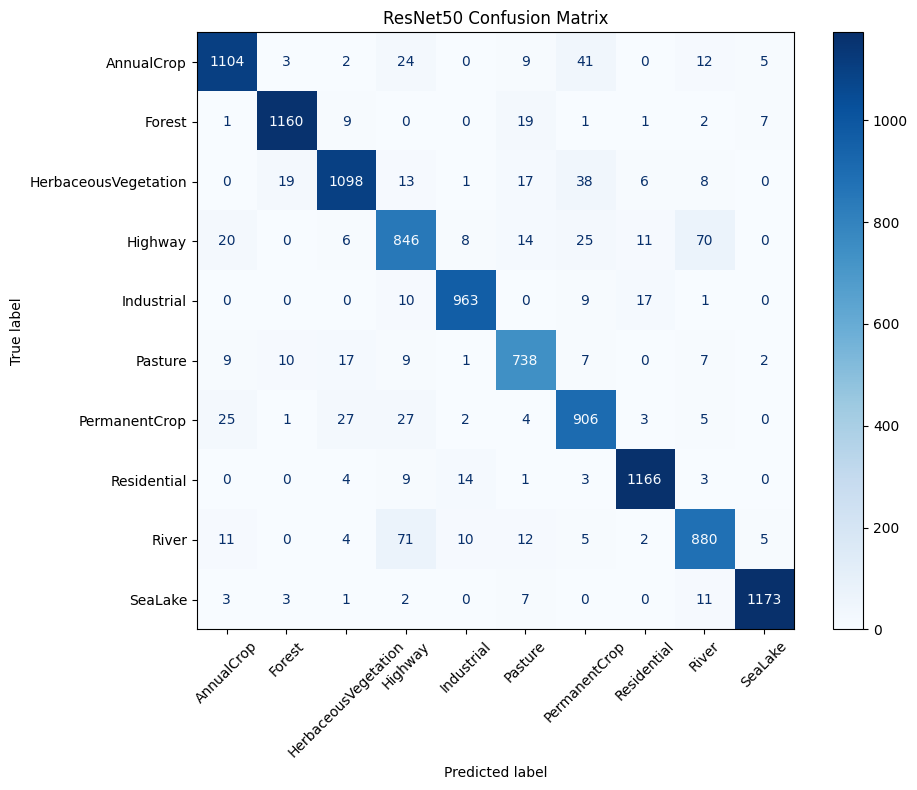

Highest misclassification: True 'River' predicted as 'Highway' (71 times).


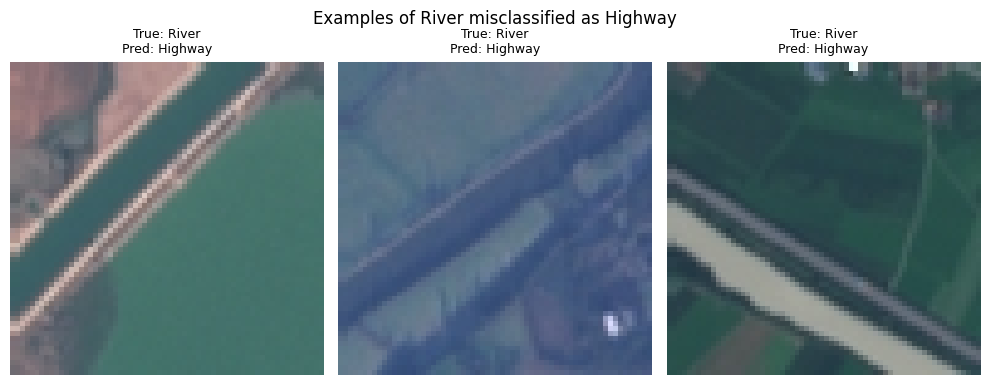

In [32]:
# Get predictions from the trained ResNet50 model
y_pred_res = model_resnet.predict(X_test_resnet)
y_pred_classes = np.argmax(y_pred_res, axis=1)
y_true_classes = np.argmax(y_test_nn, axis=1)

# Compute and plot Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('ResNet50 Confusion Matrix')
plt.tight_layout()
plt.show()

# Find the pair of classes with the highest number of misclassifications
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0) # Ignore correct predictions
max_err_idx = np.unravel_index(np.argmax(cm_errors), cm_errors.shape)
true_err_class = CLASS_NAMES[max_err_idx[0]]
pred_err_class = CLASS_NAMES[max_err_idx[1]]
num_errors = cm_errors[max_err_idx]

print(f"Highest misclassification: True '{true_err_class}' predicted as '{pred_err_class}' ({num_errors} times).")

# Show 3 examples of this specific misclassification
misclassified_idx = np.where((y_true_classes == max_err_idx[0]) & (y_pred_classes == max_err_idx[1]))[0]
fig, axes = plt.subplots(1, min(3, len(misclassified_idx)), figsize=(10, 4))
if len(misclassified_idx) == 1:
    axes = [axes]
for ax, idx in zip(axes, misclassified_idx[:3]):
    ax.imshow(X_rgb_test[idx])
    ax.set_title(f"True: {true_err_class}\nPred: {pred_err_class}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"Examples of {true_err_class} misclassified as {pred_err_class}")
plt.tight_layout()
plt.show()

#### 3.2.2 Reflection

**Model Performance & Comparison to CNN:**
- The ResNet50 transfer learning model achieved an outstanding test accuracy of approximately **92.91%**, delivering a substantial improvement over our custom CNN model (**~83.9%**).
- This leap in performance demonstrates the power of Transfer Learning. By leveraging pre-trained weights from ImageNet, the ResNet50 model already possesses highly optimized feature extractors for complex visual patterns. It only needed to adapt its final dense layers to map these features to our specific land cover classes, bypassing the need to learn basic geometric shapes from scratch.

**Highest Labeling Errors & Strategies:**
- Based on the confusion matrix, the highest labeling error occurs between **True 'River'** and **Predicted 'Highway'** (misclassified 71 times).
- **Why this happens:** In low-resolution RGB satellite imagery, both rivers and highways often manifest as long, continuous, and sometimes meandering linear features crossing the landscape. Depending on water depth, sediment, and lighting conditions, a river can appear dark or grey, sharing highly similar geometric profiles and color textures with paved asphalt highways.
- **Strategies to address this:**
  Utilize Multispectral Data: This is the most effective strategy (explored in Section 3.3). Non-visible bands (such as Near-Infrared or specific water indices) are strongly absorbed by water but reflect differently on man-made surfaces, providing distinctly different spectral signatures for water bodies compared to the concrete/asphalt of highways.

### 3.3 Multispectral Images

Although the transfer learning model achieved the highest accuracy in the previous section, ResNet50 pre-trained architecture strictly expects 3-channel input (RGB). Adapting it to accept our 13-band multispectral images would require discarding or heavily modifying the pre-trained early convolutional layers, which defeats the primary purpose of transfer learning.

Therefore, for this section, we applied the framework of our second-best performing model: the **Convolutional Neural Network (CNN)** developed in Section 3.2.1. We adjusted the input layer of this CNN architecture to accept 13 channels instead of 3. This allows the model to learn spatial and spectral features directly from the full multispectral dataset from scratch.

In [33]:
# Set the path to the Multispectral dataset
MS_DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/musa650-eurosat/eurosat_files/EuroSAT_MS")

# Load Multispectral data (13 bands)
images_ms, labels_ms = [], []
for cls in CLASS_NAMES:
    cls_dir = MS_DATA_DIR / cls
    if not cls_dir.exists():
        continue
    for img_path in sorted(cls_dir.iterdir()):
        if img_path.suffix.lower() in {".tif", ".tiff"}:
            # Load image - shape is usually (64, 64, 13)
            img = tifffile.imread(str(img_path))
            images_ms.append(img)
            labels_ms.append(CLASS_TO_IDX[cls])

X_ms_all = np.array(images_ms, dtype='float32') / 10000.0
y_ms_all = np.array(labels_ms)

In [34]:
# Split into Train / Test sets (60/40 stratified)
idx_train_ms, idx_test_ms = train_test_split(
    np.arange(len(X_ms_all)),
    test_size=0.40,
    stratify=y_ms_all,
    random_state=SEED
)

X_ms_orig_train, X_ms_orig_test = X_ms_all[idx_train_ms], X_ms_all[idx_test_ms]
y_ms_orig_train, y_ms_orig_test = y_ms_all[idx_train_ms], y_ms_all[idx_test_ms]

# Apply augmentation to the training set only
# ImageDataGenerator works for 13 channels as well
def augment_ms_subset(X_subset, y_subset):
    aug_imgs = []
    for i in range(len(X_subset)):
        img_expanded = np.expand_dims(X_subset[i], axis=0)
        aug_iter = datagen.flow(img_expanded, batch_size=1, seed=SEED)
        aug_imgs.append(next(aug_iter)[0])
    return (
        np.concatenate([X_subset, np.array(aug_imgs)], axis=0),
        np.concatenate([y_subset, y_subset], axis=0),
    )

X_ms_train_aug, y_ms_train_raw = augment_ms_subset(X_ms_orig_train, y_ms_orig_train)

# Keep the test set unchanged
X_ms_test = X_ms_orig_test
y_ms_test_raw = y_ms_orig_test

# One-hot encode labels
y_train_ms = to_categorical(y_ms_train_raw, num_classes)
y_test_ms = to_categorical(y_ms_test_raw, num_classes)

print("Multispectral Augmented Train shape:", X_ms_train_aug.shape)
print("Multispectral Original Test shape:", X_ms_test.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:622: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (1, 64, 64, 13) (13 channels).
  warnings.warn(


Multispectral Augmented Train shape: (32400, 64, 64, 13)
Multispectral Original Test shape: (10800, 64, 64, 13)


In [35]:
# Build CNN Model for Multispectral Data (13 channels)
# Using the same architecture as 3.2.1
num_channels = X_ms_train_aug.shape[-1]

model_ms_cnn = Sequential([
    # First Convolutional layer - adapted for 13 channels
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, num_channels)),
    MaxPooling2D((2, 2)),

    # Second convolutional layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Dropout for regularization
    Dropout(0.25),

    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile Model
model_ms_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Visualization
model_ms_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,322 (6.22 MB)

 Trainable params: 1,629,322 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Training on Augmented Multispectral Data
checkpoint_ms_cnn = ModelCheckpoint('best_ms_cnn.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

print("\nTraining Multispectral CNN model...")
history_ms_cnn = model_ms_cnn.fit(
    X_ms_train_aug, y_train_ms,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint_ms_cnn],
    verbose=1
)

# 5. Evaluation
if os.path.exists('best_ms_cnn.keras'):
    model_ms_cnn.load_weights('best_ms_cnn.keras')

test_loss_ms_cnn, test_acc_ms_cnn = model_ms_cnn.evaluate(X_ms_test, y_test_ms, verbose=0)
print(f"\nMultispectral CNN Test Accuracy: {test_acc_ms_cnn:.4f}")


Training Multispectral CNN model...
Epoch 1/50
806/810 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5517 - loss: 1.2754
Epoch 1: val_accuracy improved from None to 0.79136, saving model to best_ms_cnn.keras

Epoch 1: finished saving model to best_ms_cnn.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6477 - loss: 1.0107 - val_accuracy: 0.7914 - val_loss: 0.6229
Epoch 2/50
803/810 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7739 - loss: 0.6581
Epoch 2: val_accuracy improved from 0.79136 to 0.83549, saving model to best_ms_cnn.keras

Epoch 2: finished saving model to best_ms_cnn.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7856 - loss: 0.6250 - val_accuracy: 0.8355 - val_loss: 0.4686
Epoch 3/50
808/810 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8290 - loss: 0.5175
Epoch 3: val_accuracy improved from 0.83549 to 0.84414, saving model to best_ms_cnn.keras

Epoch 3: finished saving model to best_ms_cnn.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - a

#### 3.3 Reflection

**Impact of Multispectral Channels on Performance:**
Adding multispectral channels drastically improved the model's performance. Using the exact same custom CNN architecture from Section 3.2.1, the test accuracy jumped from approximately **83.9%** (on RGB data) to **92.6%** (on 13-band multispectral data). Remarkably, this relatively simple CNN trained from scratch on multispectral data even outperformed the powerful ResNet50 transfer learning model trained on RGB data (~92.4%).

**The Role of Additional Spectral Information:**
Standard RGB images only capture a small fraction of the electromagnetic spectrum (visible light). Multispectral imagery, such as the 13 bands from Sentinel-2, includes non-visible wavelengths like Near-Infrared (NIR) and Short-Wave Infrared (SWIR).
*   **Vegetation Detection:** The NIR band is highly reflected by healthy vegetation (due to chlorophyll), making it incredibly effective for differentiating between various flora types (e.g., Forest vs. Pasture vs. HerbaceousVegetation).
*   **Material Differentiation:** SWIR bands are sensitive to moisture content and can easily distinguish between bare soil (e.g., harvested 'AnnualCrop' fields) and man-made concrete/asphalt structures (e.g., 'Industrial' or 'Highway'). This directly addresses the primary labeling error we encountered in the purely RGB model.

By providing these rich, highly specific spectral signatures, the model no longer has to rely solely on spatial shapes and visible colors, leading to much more accurate and robust land cover classification.

## 4. Project Reflection

**Takeaways from Tuning and Model Choice:**
- The traditional machine learning models worked well on the reduced three-class grayscale task. The binary SVMs showed that pairs involving Forest were much easier to separate than Residential vs Industrial, and the Random Forest achieved the strongest traditional ML result with **0.912** accuracy. This suggests that some class boundaries are already fairly distinct after preprocessing, while others remain visually ambiguous.
- For the fully connected neural networks on grayscale images, adding more layers did not improve performance. The single-layer model performed best at **0.2966**, followed by the two-layer model at **0.2531**, while the deeper four-layer model with dropout dropped to **0.1798**. This indicates that increasing depth on flattened grayscale inputs adds complexity without preserving the spatial information needed for strong image classification.

**Observations on Training Epochs:**
- Increasing the number of training epochs generally helped during the early stages of training, but performance eventually plateaued and sometimes became unstable. Using `ModelCheckpoint` was important because it allowed us to evaluate the best-performing weights rather than simply using the final epoch. This was especially helpful for the CNN-based models, where validation accuracy changed noticeably across epochs.

**Impact of Dropout:**
- Dropout had mixed effects depending on the model. In the deeper fully connected grayscale network, dropout hurt performance because the model was already weak and the flattened representation was not very informative. In contrast, dropout was more useful in the CNN and transfer-learning models, where it acted as regularization without preventing the network from learning strong visual features.

**Ensemble Performance:**
- The soft-voting ensemble of the three grayscale fully connected models achieved **0.2780** accuracy. Although ensembling can improve robustness, it did not outperform the best individual model here because the weaker networks lowered the quality of the combined predictions. This shows that an ensemble is only as effective as the models contributing to it.

**Challenges and Limitations:**
- A major challenge throughout the assignment was that several land-cover classes share similar visual patterns, especially in grayscale or RGB-only settings. This was visible in both the traditional ML results and the deep learning confusion patterns. Another limitation was computational cost: training larger CNNs and working with 13-channel multispectral imagery required more time and memory than the simpler baseline models.

**Applying These Lessons to Future Work:**
- The strongest overall RGB model was the ResNet50 transfer-learning model, which achieved **0.9291** test accuracy, while the multispectral CNN reached **0.9259**. The multispectral model clearly improved over the custom RGB CNN (**0.8392**), showing that extra spectral information is valuable, but in this run it still slightly trailed the pre-trained ResNet. In future work, we can compute spectral indices such as NDVI and NDWI from the multispectral bands and expand the input layer to include these additional channels. This may help the model better distinguish vegetation, water, and built-up areas. And fine tuning strategy with other backbone model also can be explored further.
